In [2]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

import matplotlib
matplotlib.rcParams.update({'font.size': 15})
matplotlib.rc('xtick', labelsize=15)
import matplotlib.pyplot as plt

from ACI_algo_v1 import infoACI_precompute_q

In [3]:
p = 2
proby = np.array((.8, .2))
def generate_dataset(n, p):
    Y = np.random.choice(np.array((0, 1)), p=proby, size=n)
    X = []
    for i in range(n):
        if Y[i] == 0:
            X.append(np.random.normal(0, 1, size=p))
        elif Y[i] == 1:
            X.append(np.random.normal(3, 1, size=p))
    X = np.array(X)
    return X, Y

In [4]:
def Score_func(y_pred, y, x):
     if len(y_pred.shape) > 1:
        return y_pred[:, 1]
     else: 
        return y_pred[1]

def info_fun(y_pred, y, x, s, q):
    return (s > q)*1

def Error_func(y_pred, y, x, s, q):
    return (y == 0)*1

In [5]:
np.random.seed(1)
n = 10000
X, Y = generate_dataset(n, p)

Xt = X[:].copy()
Yt = Y[:len(Xt)].copy()

dates = np.arange(len(Xt))
T = len(Xt)

update = True
Scoret = np.zeros(len(Xt))
Ypredt = np.zeros(len(Xt))
for t in range(len(Xt)):
    if update:
        if t <= 100:
            clf = RandomForestClassifier(random_state=0).fit(Xt[:np.fmax(20, t)], Yt[:np.fmax(20, t)])
    pred =  clf.predict_proba(Xt[t].reshape((-1, p)))[0]
    Ypredt[t] = np.argmax(pred)*0 + 1
    Scoret[t] = Score_func(pred, Yt, Xt)

In [6]:
# Create a DataFrame from the generated data
c_names = ['date']
for i in range(p):
    c_names.append('value_' + str(i))

dt_Xt = np.vstack((dates.T, Xt.T)).T
dt_Xt = pd.DataFrame(dt_Xt, columns=c_names)
# Set the 'date' column as the index
dt_Xt.set_index('date', inplace=True)

# Create a DataFrame from the generated data
dt_Yt = pd.DataFrame({'date': dates, 'value': Yt})
# Set the 'date' column as the index
dt_Yt.set_index('date', inplace=True)

# Create a DataFrame from the generated data
dt_Ypredt = pd.DataFrame({'date': dates, 'value': Ypredt})
# Set the 'date' column as the index
dt_Ypredt.set_index('date', inplace=True)

# Create a DataFrame from the ge5nerated data
dt_Scoret = pd.DataFrame({'date': dates, 'value': Scoret})
# Set the 'date' column as the index
dt_Scoret.set_index('date', inplace=True)

In [7]:
# infoACI
alpha = .1
t_range = np.arange(1, T+1)
gamma = 1/(t_range**(3/4))
dt_Qt_infoACIq, dt_errt_infoACIq, dt_infot_infoACIq = infoACI_precompute_q(dt_Xt, dt_Yt, dt_Ypredt, dt_Scoret, info_fun, Error_func, gamma, alpha, q0=.5)

2105


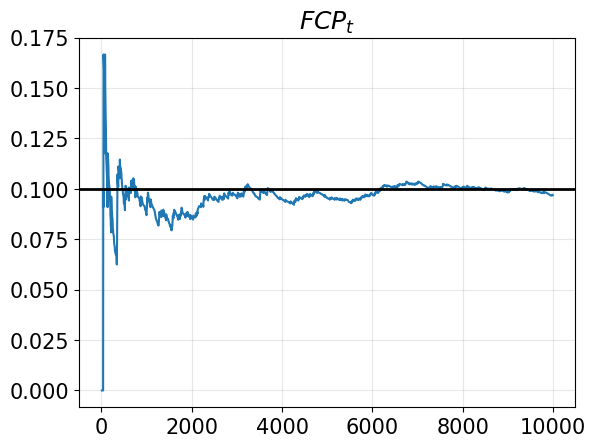

In [8]:
ind_select = np.where(dt_infot_infoACIq['value']==1)[0]
print(len(ind_select))

plt.plot( (np.cumsum(dt_errt_infoACIq['value'][ind_select])/np.arange(1, len(ind_select)+1))[:])
plt.axhline(alpha, color='k', lw=2)
plt.title('$FCP_t$')
plt.grid(alpha=.3)

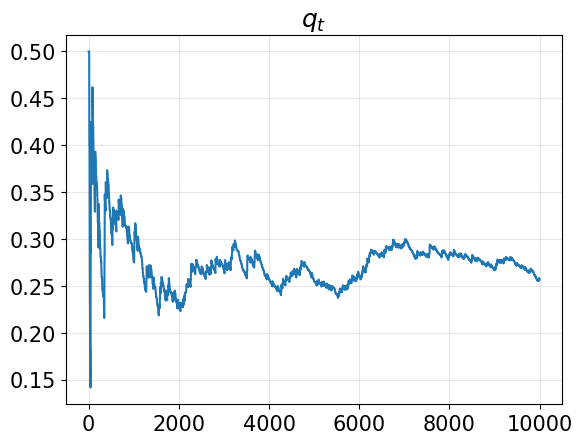

In [9]:
plt.plot(dt_Qt_infoACIq['value'][:])
plt.title('$q_t$')
plt.grid(alpha=.3)

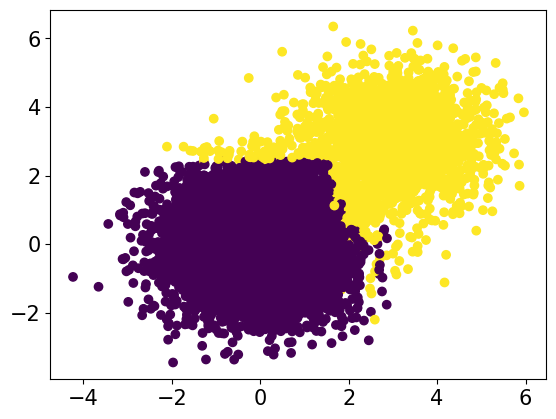

In [10]:
plt.scatter(X[:, 0], X[:, 1], c = dt_infot_infoACIq.values[:])